In [13]:
import matplotlib.pyplot as plt
import pandas as pd

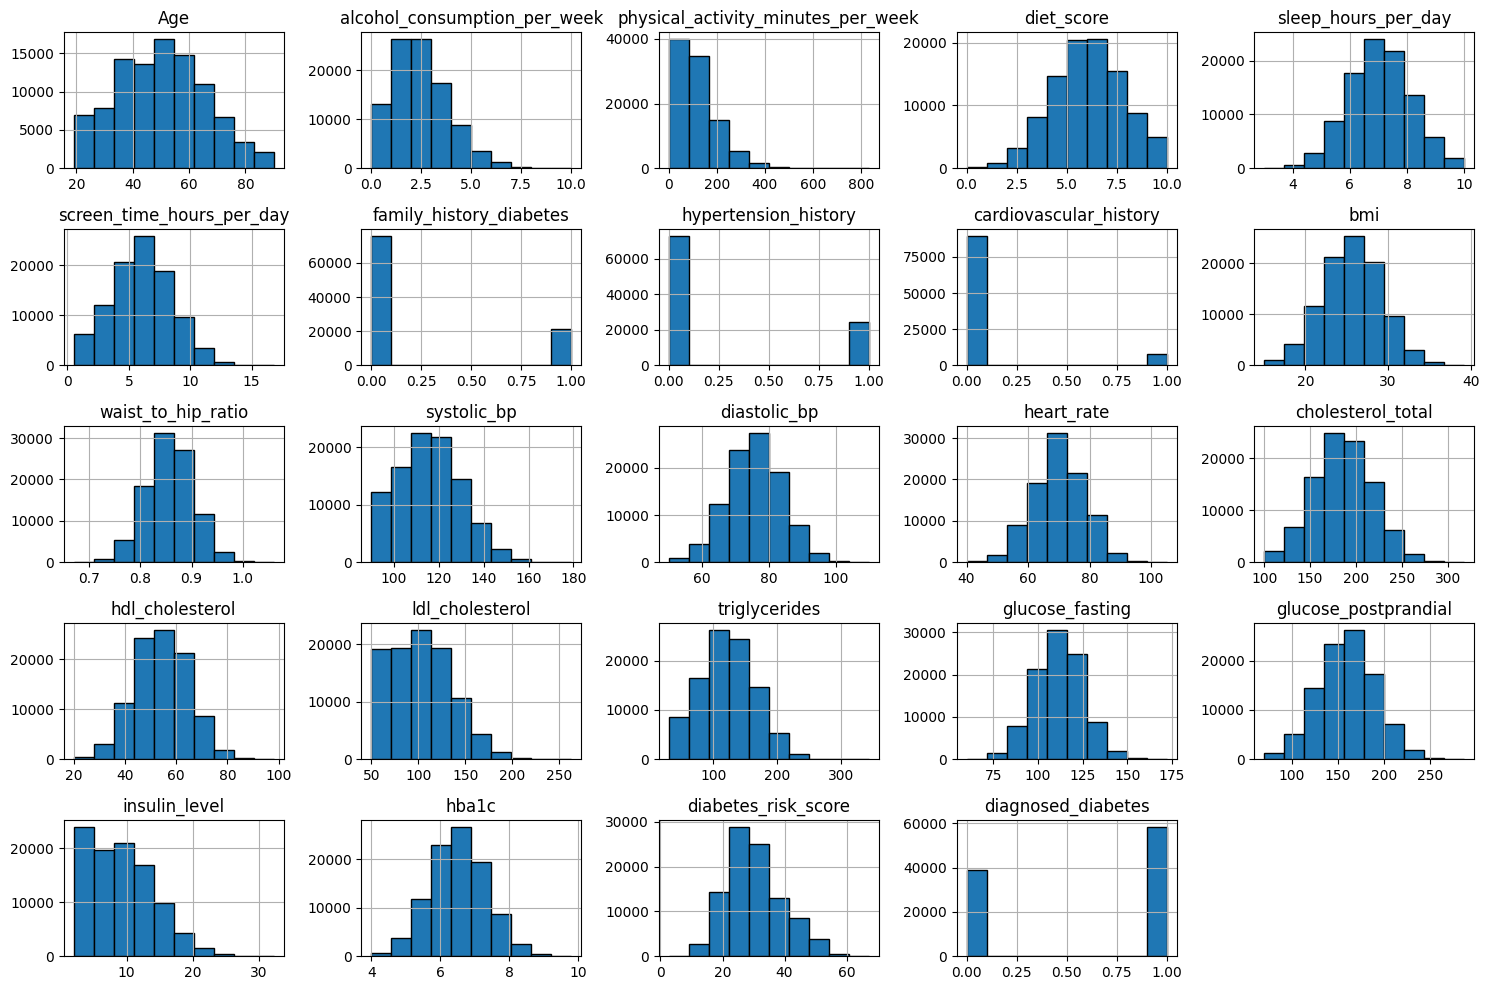

In [15]:
df = pd.read_csv('data/Diabetes_and_LifeStyle_Dataset.csv', encoding='utf-8')

df.hist(edgecolor="black", figsize=(15, 10))
plt.tight_layout()
plt.show()


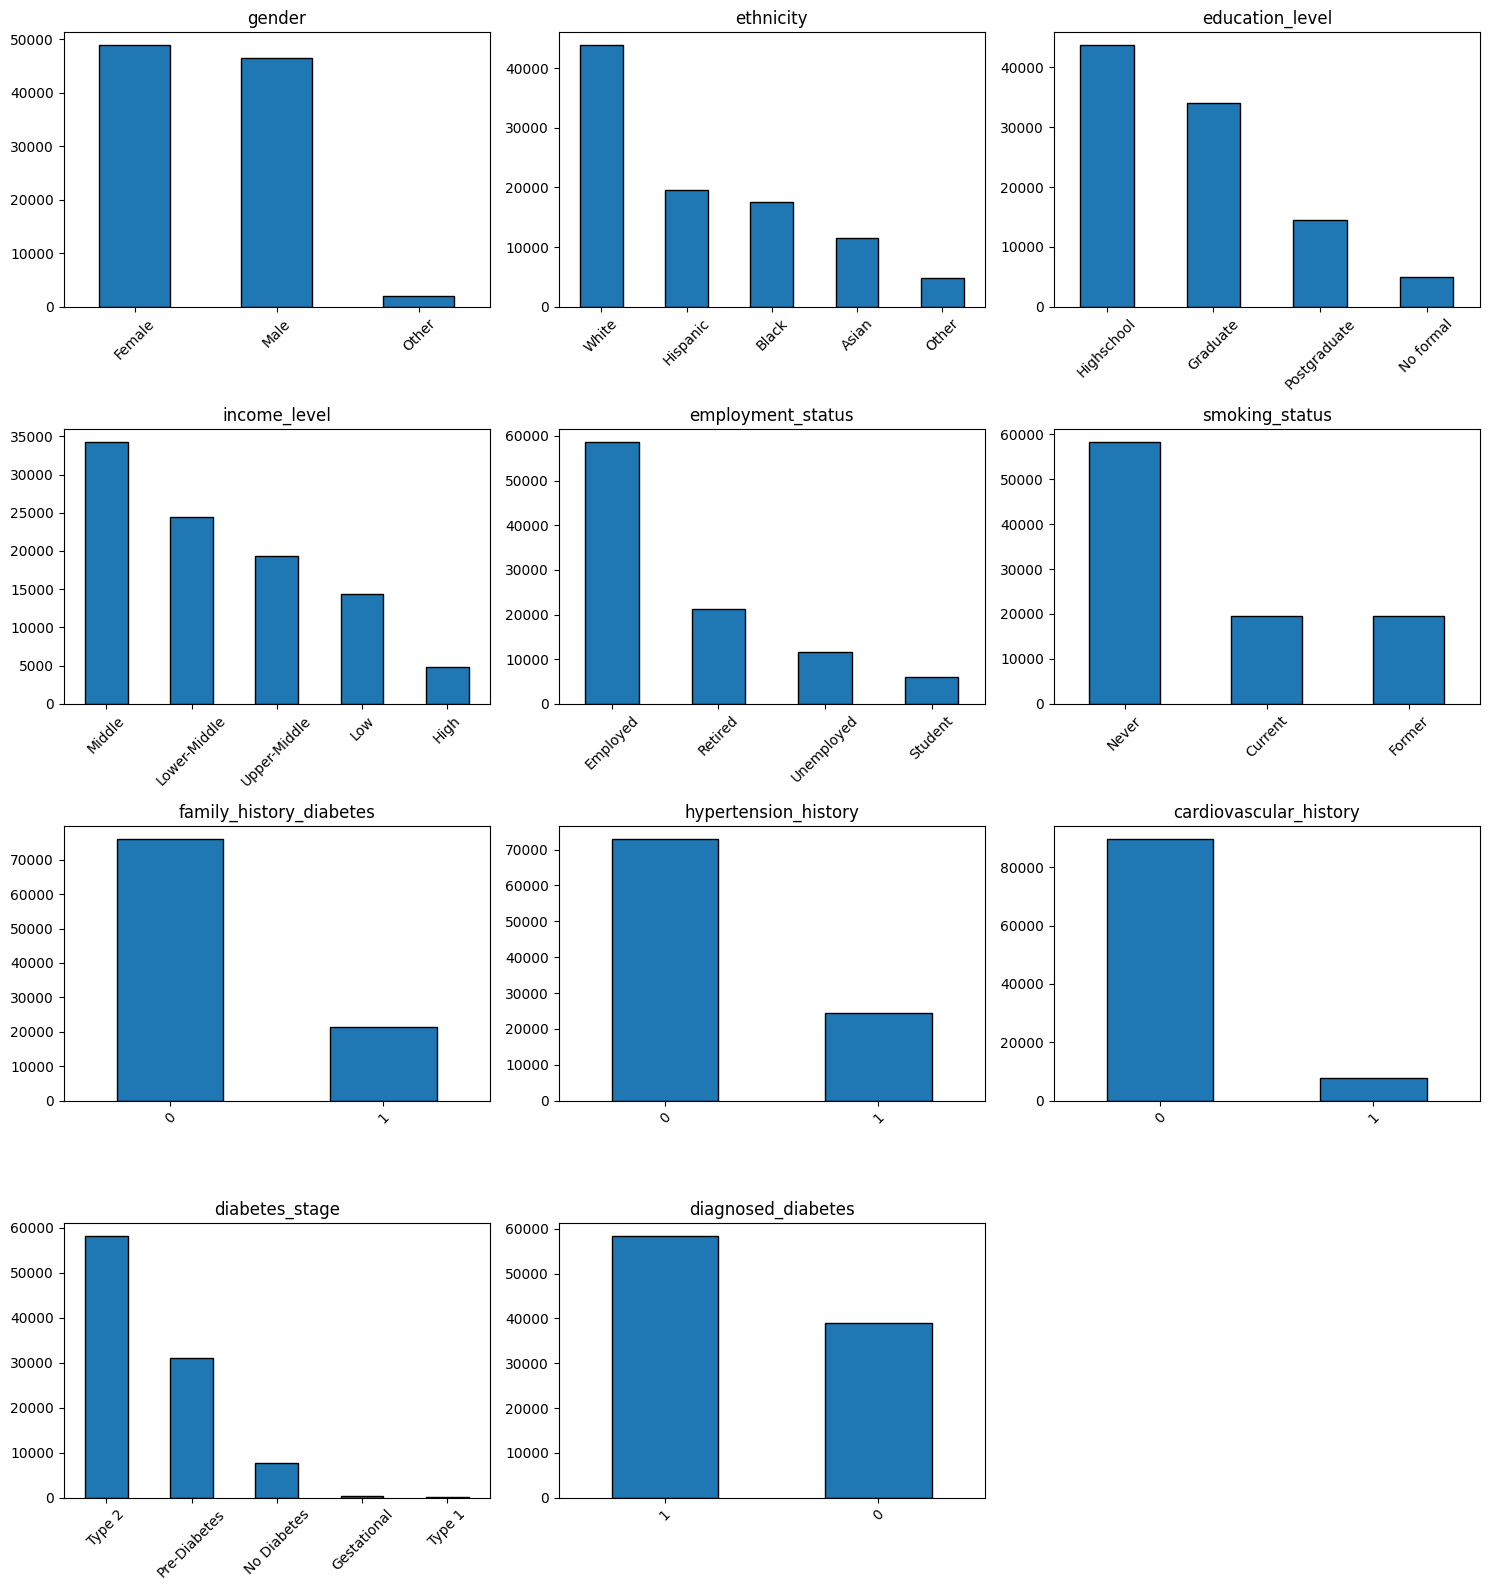

In [16]:
import math

# Colonnes catégorielles : texte, ou numériques avec peu de valeurs distinctes (ex. 0/1)
cat_cols = [c for c in df.columns if df[c].dtype == 'object' or df[c].nunique() <= 10]

ncols = 3
nrows = math.ceil(len(cat_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), squeeze=False)
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)  # masque les cases vides de la grille

plt.tight_layout()
plt.show()

In [21]:
valeurs_manquantes = df.isna().sum().sum()
print("Nombre de valeurs manquantes dans le jeu de données :", valeurs_manquantes)

Nombre de valeurs manquantes dans le jeu de données : 0


                                         Age  alcohol_consumption_per_week  \
Age                                 1.000000                      0.000774   
alcohol_consumption_per_week        0.000774                      1.000000   
physical_activity_minutes_per_week  0.003020                     -0.002082   
diet_score                         -0.003175                     -0.000311   
sleep_hours_per_day                -0.003505                      0.001837   
screen_time_hours_per_day          -0.006167                      0.001794   
family_history_diabetes            -0.002675                      0.003062   
hypertension_history                0.177312                     -0.007438   
cardiovascular_history              0.147476                     -0.005129   
bmi                                 0.093728                     -0.002852   
waist_to_hip_ratio                  0.070225                     -0.003895   
systolic_bp                         0.547095                    

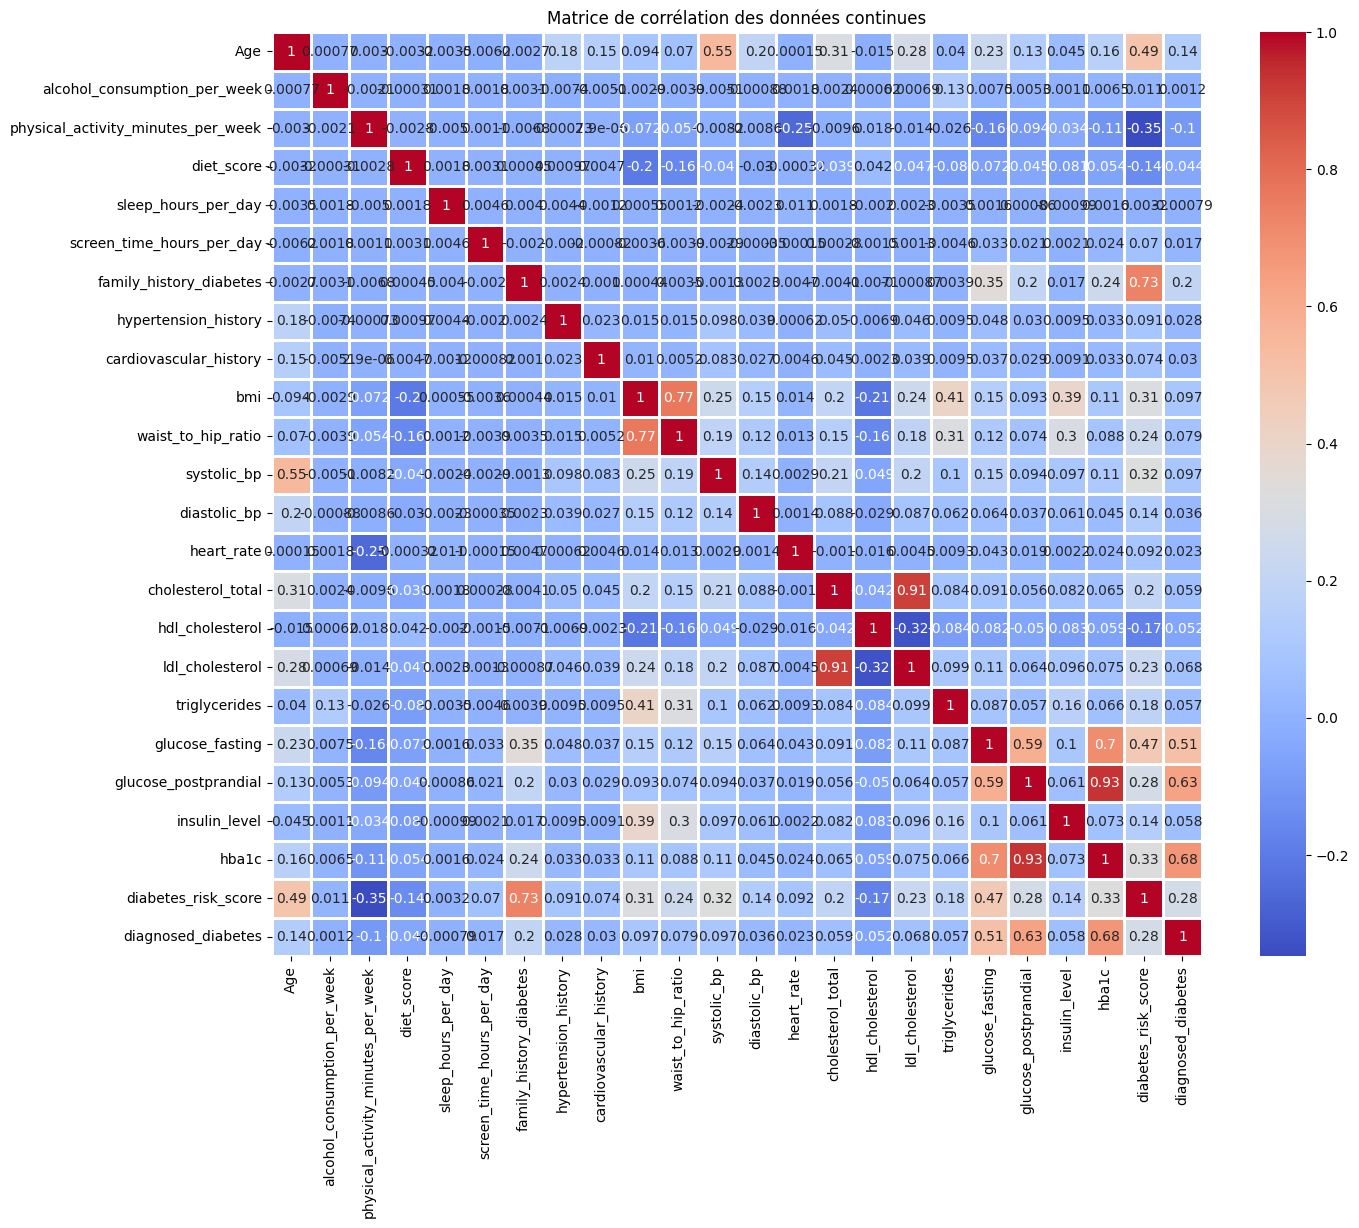

In [29]:
#Matrice de correlation
import seaborn 
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

plt.figure(figsize=(15, 12))
seaborn.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidth=2)
plt.title("Matrice de corrélation des données continues")
plt.show()